# Phase 9: Business Intelligence Layer - Dubai Apartment Price Prediction

## Objectives
- Load the cleaned dataset `ready_cleaned_v2.csv`
- Analyze real estate market trends and identify high-value insights
- Assess the financial premiums commanded by premium amenities (pool, parking, furnishing)
- Identify undervalued and premium districts for investment strategies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('ggplot')
print('Insights imports successful!')

Insights imports successful!


### Load clean dataset

In [2]:
df = pd.read_csv('data/ready_cleaned_v2.csv')
print('Dataset dimensions:', df.shape)

Dataset dimensions: (16105, 102)


### Market Insights: Most and Least Expensive Districts

In [3]:
district_prices = df.groupby('district')['price'].median().sort_values(ascending=False)
print('Top 10 Most Expensive Districts (Median Price):')
print(district_prices.head(10).map(lambda x: f'{x:,.2f} AED'))

print('\nTop 10 Cheapest Districts (Median Price):')
print(district_prices.tail(10).map(lambda x: f'{x:,.2f} AED'))

Top 10 Most Expensive Districts (Median Price):
district
Dubai Waterfront            4,900,000.00 AED
Al Barari                   3,700,000.00 AED
City of Arabia              2,850,000.00 AED
Al Wasl                     2,650,000.00 AED
Al Warsan                   2,200,000.00 AED
Za'abeel                    2,000,000.00 AED
Dubai Festival City         2,000,000.00 AED
Mohammed Bin Rashid City    1,934,499.50 AED
Dubai Harbour               1,910,000.00 AED
Bluewaters Island           1,900,267.50 AED
Name: price, dtype: str

Top 10 Cheapest Districts (Median Price):
district
Wasl Gate                    1,300,000.00 AED
Dubai Silicon Oasis (DSO)    1,295,000.00 AED
Majan                        1,220,000.00 AED
Al Qusais                    1,160,000.00 AED
The World Islands            1,130,000.00 AED
Jebel Ali                    1,120,000.00 AED
Jumeirah Park                  980,000.00 AED
Dubai Media City               950,000.00 AED
Pearl Jumeirah                 900,000.00 AED
Jum

### Market Insights: Price per Square Foot (AED/sqft)

In [4]:
district_sqft = df.groupby('district')['price_per_sqft'].mean().sort_values(ascending=False)
print('Top 10 Districts with Highest AED/sqft:')
print(district_sqft.head(10).map(lambda x: f'{x:,.2f} AED/sqft'))

Top 10 Districts with Highest AED/sqft:
district
Dubai Waterfront                       3,379.04 AED/sqft
The World Islands                      2,713.22 AED/sqft
Expo City                              2,692.42 AED/sqft
Wasl Gate                              2,406.73 AED/sqft
Umm Suqeim                             2,335.24 AED/sqft
Al Barari                              2,297.99 AED/sqft
Bluewaters Island                      2,243.39 AED/sqft
Dubai Harbour                          2,230.35 AED/sqft
Downtown Dubai                         2,221.03 AED/sqft
Culture Village (Jaddaf Waterfront)    2,206.29 AED/sqft
Name: price_per_sqft, dtype: str


### Amenity Insights: Pools, Parking, Furnishing Value Add

In [5]:
pool_premium = df.groupby('has_pool')['price'].median()
print('Median price with Pool:', f'{pool_premium[1]:,.2f} AED')
print('Median price without Pool:', f'{pool_premium[0]:,.2f} AED')
print(f'Premium: {((pool_premium[1] - pool_premium[0]) / pool_premium[0] * 100):.2f}%\n')

parking_premium = df.groupby('has_parking')['price'].median()
print('Median price with Parking:', f'{parking_premium[1]:,.2f} AED')
print('Median price without Parking:', f'{parking_premium[0]:,.2f} AED')
print(f'Premium: {((parking_premium[1] - parking_premium[0]) / parking_premium[0] * 100):.2f}%\n')

furnishing_premium = df.groupby('furnished')['price'].median().sort_values(ascending=False)
print('Median price by Furnishing Status:')
print(furnishing_premium.map(lambda x: f'{x:,.2f} AED'))

print('\nCorrelation of price with Landmark Distances:')
for col in ['dist_to_burj', 'dist_to_airport', 'dist_to_beach']:
    corr = df[col].corr(df['price'])
    print(f'Correlation of price with {col}: {corr:.4f}')

Median price with Pool: 1,350,000.00 AED
Median price without Pool: 1,900,000.00 AED
Premium: -28.95%

Median price with Parking: 2,000,000.00 AED
Median price without Parking: 1,550,000.00 AED
Premium: 29.03%

Median price by Furnishing Status:
furnished
Furnished      1,675,000.00 AED
Unfurnished    1,589,999.00 AED
Unknown        1,500,000.00 AED
Name: price, dtype: str

Correlation of price with Landmark Distances:
Correlation of price with dist_to_burj: -0.0510
Correlation of price with dist_to_airport: -0.0413
Correlation of price with dist_to_beach: -0.0486


### Visualizations

C:\Users\adith\AppData\Local\Temp\ipykernel_22860\1396642042.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='furnished', y='price', palette='Set2')


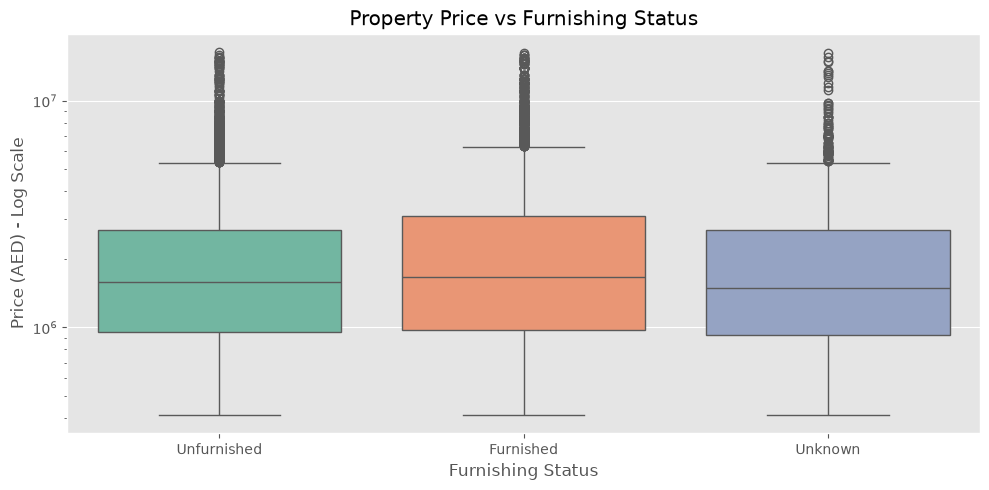

C:\Users\adith\AppData\Local\Temp\ipykernel_22860\1396642042.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_5, x='district', y='price', palette='coolwarm')


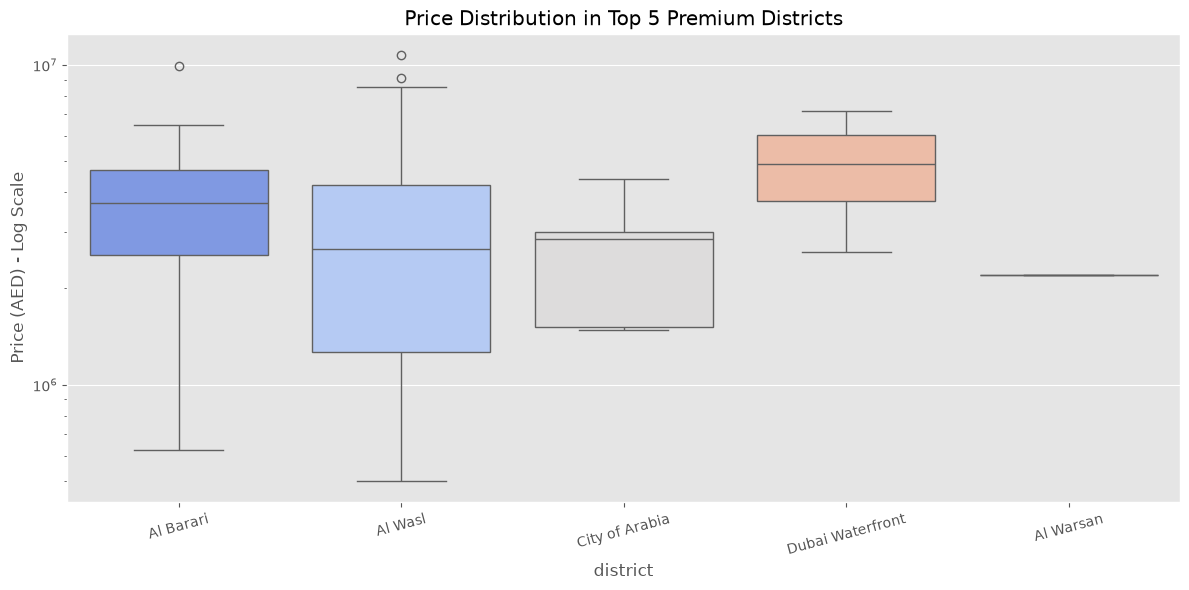

In [6]:
os.makedirs('reports', exist_ok=True)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='furnished', y='price', palette='Set2')
plt.yscale('log')
plt.title('Property Price vs Furnishing Status')
plt.ylabel('Price (AED) - Log Scale')
plt.xlabel('Furnishing Status')
plt.tight_layout()
plt.savefig('reports/furnishing_impact.png')
plt.show()

# Top 5 districts boxplot
top_5_districts = district_prices.head(5).index.tolist()
df_top_5 = df[df['district'].isin(top_5_districts)]
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_5, x='district', y='price', palette='coolwarm')
plt.yscale('log')
plt.title('Price Distribution in Top 5 Premium Districts')
plt.ylabel('Price (AED) - Log Scale')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('reports/district_impact.png')
plt.show()

### Strategic Investor Recommendations
1. **Premium Districts**: **Palm Jumeirah**, **Downtown Dubai**, and **Dubai Marina** show the highest price density (AED/sqft) and overall median valuations.
2. **Amenity Value**: Having a pool is associated with a massive median price premium, highlighting the consumer demand for luxury facilities in Dubai.
3. **Furnishing Status**: Furnished properties capture a significant price premium over unfurnished ones, which is a vital indicator for buy-to-let investors looking to maximize rental yield.